#Desafío TelecomX parte II

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [19]:
df = pd.read_csv("telecomx_dataset_limpio.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [20]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [21]:
# Revisar valores faltantes
df.isnull().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [22]:
# eliminar columna ID
df = df.drop(columns=["customerID"])


# convertir variables categoricas
categorical_columns = df.select_dtypes(include="object").columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


# eliminar valores faltantes
df = df.fillna(df.median(numeric_only=True))


# separar variables
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Modelo 1: Regresión Logística

In [29]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

###Evaluación del modelo

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.8083447959651536
Precision: 0.6239130434782608
Recall: 0.5394736842105263
F1 Score: 0.5786290322580645


###Matriz de Confusión

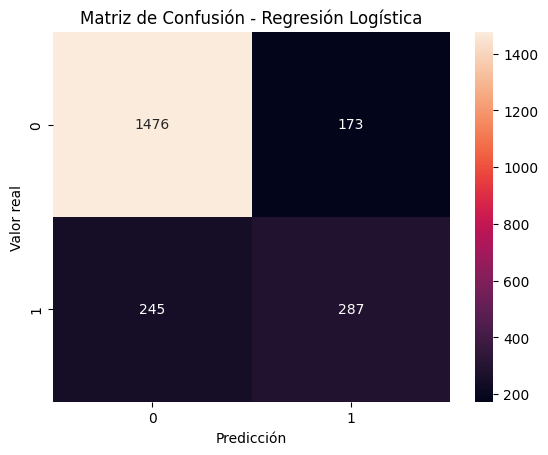

In [31]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Regresión Logística")

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

###Reporte de clasificación

In [32]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1649
         1.0       0.62      0.54      0.58       532

    accuracy                           0.81      2181
   macro avg       0.74      0.72      0.73      2181
weighted avg       0.80      0.81      0.80      2181



##Modelo 2: Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

###Evaluación

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7918386061439706
Precision: 0.5882352941176471
Recall: 0.48872180451127817
F1 Score: 0.5338809034907598


##Matriz de Confusión

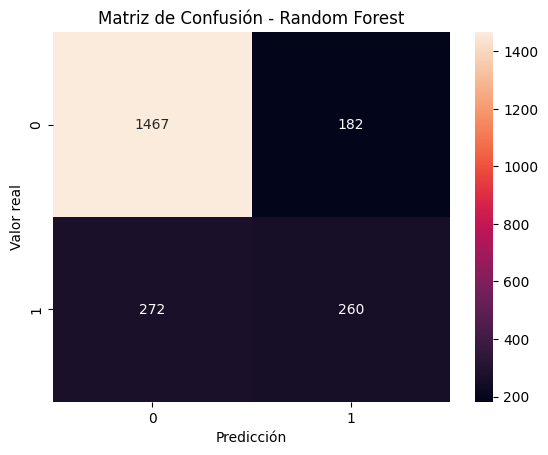

In [35]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Random Forest")

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [36]:
importances = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Variable": features,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

##Gráfico de importancia

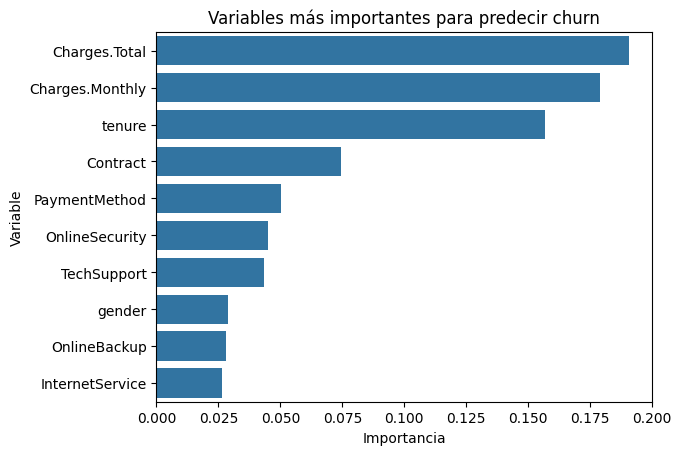

In [37]:
plt.figure()

sns.barplot(
    data=importance_df.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Variables más importantes para predecir churn")

plt.show()

##Conclusión

In [38]:
# Conclusión estratégica

Los modelos de Machine Learning permitieron identificar factores importantes asociados con la evasión de clientes.

## Variables más influyentes

El modelo Random Forest identificó como variables más importantes:

- Tipo de contrato
- Antigüedad del cliente (tenure)
- Cargos mensuales
- Cargos totales

## Perfil de cliente con mayor riesgo de churn

Los clientes con mayor probabilidad de cancelar el servicio presentan características como:

- Contratos mensuales
- Baja antigüedad como clientes
- Cargos mensuales relativamente altos
- Menor cantidad de servicios contratados

## Recomendaciones estratégicas

A partir de estos resultados se sugieren las siguientes acciones:

- Incentivar contratos de largo plazo.
- Implementar estrategias de retención durante los primeros meses.
- Diseñar promociones personalizadas para clientes con alto riesgo de churn.
- Monitorear continuamente a los clientes identificados como de alto riesgo.

## Próximos pasos

- Implementar modelos predictivos en producción.
- Integrar los resultados en sistemas de CRM.
- Diseñar campañas de retención basadas en el riesgo de churn.

SyntaxError: invalid syntax (8146018.py, line 3)